<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# import importlib
# import cellsweep.celltype_ambient
# importlib.reload(cellsweep.celltype_ambient)
# from cellsweep.celltype_ambient import denoise_count_matrix

# import importlib
# import cellsweep.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# importlib.reload(cs_utils)

# Compare tools

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k, hgmm_12k, kidney_nuclei_10k, melanoma, pbmc_mouse_5k, pbmc33k, simulation1_small_noise, simulation2_high_noise  # for a custom dataset, make a new yaml file with the desired config - see example template at notebooks/config/custom.yaml
alternative_tools = ["cellbender", "soupx", "decontx", "scar"]
rerun_tools = False  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False  # for CellBender and scAR
threads = 8  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
# load yaml
yaml_file = os.path.join(cellsweep_dir, "notebooks", "config", f"{dataset_name}.yaml")
cfg = cs_utils.load_dataset_yaml(yaml_file)

# create directories for data, output
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

# raw adata
if cfg.get("adata_raw_file_name") is None:
    if cfg.get("adata_raw_url") is not None:
        cfg["adata_raw_file_name"] = cfg["adata_raw_url"].split("/")[-1]
    # else:
    #     raise ValueError("If adata_raw_file_name is not specified in the config yaml, adata_raw_url must be specified.")

adata_path_raw = f"{data_dir}/{cfg['adata_raw_file_name']}" if cfg['adata_raw_file_name'] is not None else None
if adata_path_raw and not os.path.exists(adata_path_raw) and cfg["adata_raw_url"] is not None:
    !wget -O {adata_path_raw} {cfg["adata_raw_url"]}

matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
os.makedirs(matrix_tar_files_dir, exist_ok=True)

raw_tar_file_dir = None
filtered_tar_file_dir = None

sequencing_technology = cfg["sequencing_technology"]

# set file paths for tools
adata_path_cellsweep = f"{data_dir}/{cfg['adata_path_cellsweep_name']}"
cellsweep_log_file = os.path.join(data_dir, "cellsweep.log")
if cfg["remove_empties"]:
    adata_path_cellsweep = adata_path_cellsweep.replace(".h5ad", "_no_empties.h5ad")
    cellsweep_log_file = cellsweep_log_file.replace(".log", "_no_empties.log")

    if alternative_tools:
        raise ValueError("Cannot remove empty droplets when benchmarking alternative tools since other tools rely on this. Set remove_empties to False in the config yaml or set alternative_tools to [].")

adata_path_cellbender = f"{data_dir}/{cfg['adata_path_cellbender_name']}"
adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")
cellbender_ckpt = os.path.join(data_dir, "cellbender_ckpt.tar.gz")

soupx_out_prefix = f"{data_dir}/{cfg['soupx_out_prefix_name']}"
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"

decontx_out_prefix = f"{data_dir}/{cfg['decontx_out_prefix_name']}"

adata_path_scar = f"{data_dir}/{cfg['adata_path_scar_name']}"


if dataset_name == "hgmm_12k" or "ATAC_hgmm_10k":
    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    # # check if raw_tar_file_dir is empty or doesn't exist
    # if rerun_tools and (not os.path.exists(raw_tar_file_dir) or len(os.listdir(raw_tar_file_dir)) == 0) or (not os.path.exists(filtered_tar_file_dir) or len(os.listdir(filtered_tar_file_dir)) == 0):
    adata_raw = cs_utils.load_adata(adata_path_raw, gex_only = (not dataset_name == "ATAC_hgmm_10k"), verbose=verbose)
    umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=cfg["expected_cells"], show=False)
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cs_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix

if dataset_name.startswith("simulation"):
    # simulate data
    if not os.path.exists(adata_path_raw) or overwrite:
        adata_raw = simulate_cells(
            G=cfg["G"],
            N=cfg["N"],
            k=cfg["k"],
            markers_per_type=cfg["markers_per_type"],
            marker_boost=cfg["marker_boost"],
            type_proportions=cfg["type_proportions"],
            empty_prob=cfg["empty_prob"],
            alpha=cfg["alpha"],
            beta=cfg["beta"],
            expected_cell_size=cfg["expected_cell_size"],
            noise_logsd_cell=cfg["noise_logsd_cell"],
            noise_logsd_empty=cfg["noise_logsd_empty"],
            dispersion=cfg["dispersion"],
            housekeeping_frac=cfg["housekeeping_frac"],
            hk_logmean=cfg["hk_logmean"],
            hk_logsd=cfg["hk_logsd"],
            rng_seed=42,
        )
        adata_raw.write_h5ad(adata_path_raw)
    else:
        adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)

    paths = cs_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=True)

    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix


# raw and filtered matrix tar files
if cfg["raw_tar_url"] is not None and (rerun_tools or adata_path_raw is None):
    raw_tar_file_name = cfg["raw_tar_url"].split("/")[-1]
    raw_tar_path = os.path.join(matrix_tar_files_dir, raw_tar_file_name)
    if not os.path.exists(raw_tar_path):
        !wget -O {raw_tar_path} {cfg["raw_tar_url"]}
    raw_tar_dir_name = cs_utils.get_tar_top_level_dir(raw_tar_path)
    raw_tar_dir_path = os.path.join(matrix_tar_files_dir, raw_tar_dir_name)
    if not os.path.exists(raw_tar_dir_path):
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    # if folder name doesn't start with "raw_", rename it
    index = raw_tar_dir_name.find("raw_")
    if index != 0:
        raw_tar_dir_name_new = raw_tar_dir_name[index:] if index != -1 else raw_tar_dir_name
        raw_tar_dir_path_new = os.path.join(matrix_tar_files_dir, raw_tar_dir_name_new)
        if not os.path.exists(raw_tar_dir_path_new):
            os.rename(raw_tar_dir_path, raw_tar_dir_path_new)
        raw_tar_dir_name = raw_tar_dir_name_new
        raw_tar_dir_path = raw_tar_dir_path_new


if rerun_tools and raw_tar_file_dir is None:
    if cfg.get('raw_tar_file_dir_suffix') is None:
        raw_tar_file_dir = cs_utils.find_single_branch_leaf_dir(raw_tar_dir_path)
    else:
        raw_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['raw_tar_file_dir_suffix']}"

if cfg["filtered_tar_url"] is not None and rerun_tools:
    filtered_tar_file_name = cfg["filtered_tar_url"].split("/")[-1]
    filtered_tar_path = os.path.join(matrix_tar_files_dir, filtered_tar_file_name)
    if not os.path.exists(filtered_tar_path):
        !wget -O {filtered_tar_path} {cfg["filtered_tar_url"]}
    filtered_tar_dir = cs_utils.get_tar_top_level_dir(filtered_tar_path)
    filtered_tar_dir_path = os.path.join(matrix_tar_files_dir, filtered_tar_dir)
    if not os.path.exists(filtered_tar_dir_path):
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
    # if folder name doesn't start with "filtered_", rename it
    index = filtered_tar_dir.find("filtered_")
    if index != 0:
        filtered_tar_dir_name_new = filtered_tar_dir[index:] if index != -1 else filtered_tar_dir
        filtered_tar_dir_path_new = os.path.join(matrix_tar_files_dir, filtered_tar_dir_name_new)
        if not os.path.exists(filtered_tar_dir_path_new):
            os.rename(filtered_tar_dir_path, filtered_tar_dir_path_new)
        filtered_tar_dir = filtered_tar_dir_name_new
        filtered_tar_dir_path = filtered_tar_dir_path_new

if rerun_tools and filtered_tar_file_dir is None:
    if cfg.get('filtered_tar_file_dir_suffix') is None:
        filtered_tar_file_dir = cs_utils.find_single_branch_leaf_dir(filtered_tar_dir_path)
    else:
        filtered_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['filtered_tar_file_dir_suffix']}"

# lay out parameters
model_pkl = cfg["model_pkl"]
celltypist_convert = cfg["celltypist_convert"]
celltypist_map_file = cfg["celltypist_map_file"]
cellsweep_max_iter = cfg["cellsweep_max_iter"]
cellsweep_beta = cfg["cellsweep_beta"]
cellsweep_init_alpha = cfg["cellsweep_init_alpha"]
cellbender_epochs = cfg["cellbender_epochs"]
cellbender_fpr = cfg["cellbender_fpr"]
cellbender_zdim = cfg["cellbender_zdim"]
cellbender_expected_cells = cfg["cellbender_expected_cells"]
cellbender_total_droplets = cfg["cellbender_total_droplets"]
scar_epochs = cfg["scar_epochs"]
scar_prob = cfg["scar_prob"]
expected_cells = cfg["expected_cells"]
remove_empties = cfg["remove_empties"]
min_genes = cfg["min_genes"]
min_cells = cfg["min_cells"]
umi_top_percentile_to_remove = cfg["umi_top_percentile_to_remove"]
fraction_doublet = cfg["fraction_doublet"]
unique_genes_top_percentile_to_remove = cfg["unique_genes_top_percentile_to_remove"]
mt_gene_percentile_to_remove = cfg["mt_gene_percentile_to_remove"]
max_mt_percentage = cfg["max_mt_percentage"]
n_top_genes = cfg["n_top_genes"]
n_pcs = cfg["n_pcs"]
n_neighbors = cfg["n_neighbors"]
leiden_resolution = cfg["leiden_resolution"]
marker_genes = cfg["marker_genes"]

cellsweep_matrix_url = cfg["cellsweep_matrix_url"]
cellbender_matrix_filtered_url = cfg["cellbender_matrix_filtered_url"]
cellbender_ckpt_url = cfg["cellbender_ckpt_url"]
soupx_matrix_url = cfg["soupx_matrix_url"]
decontx_matrix_url = cfg["decontx_matrix_url"]
scar_matrix_url = cfg["scar_matrix_url"]

17:03:29 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5'


UMI cutoff for expected cells (8381): 1386.00
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/matrix_tar_files/combined/raw_gene_bc_matrices/combined'. Skipping write.
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/matrix_tar_files/combined/filtered_gene_bc_matrices/combined'. Skipping write.


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Raw

In [5]:
if adata_path_raw is not None and os.path.exists(adata_path_raw):
    adata_raw = cs_utils.load_adata(adata_path_raw, gex_only = (not dataset_name == "ATAC_hgmm_10k"), verbose=verbose)
elif raw_tar_file_dir is not None and os.path.exists(raw_tar_file_dir):
    adata_raw = cs_utils.load_adata(raw_tar_file_dir, gex_only = (not dataset_name == "ATAC_hgmm_10k"), verbose=verbose)
else:
    raise ValueError("No raw data found.")
adata_raw.var_names_make_unique()

17:03:30 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate umi_cutoff

UMI cutoff for expected cells (8381): 1386.00


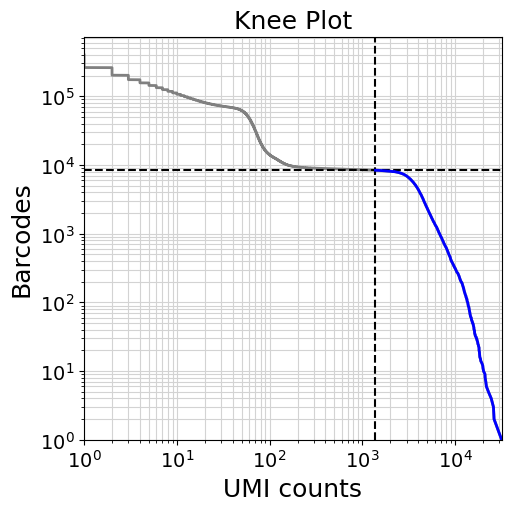

In [6]:
umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, transpose=True, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot
if not dataset_name.startswith("simulation"):
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

# cs_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
# cs_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

if remove_empties:
    adata_raw = adata_raw[~adata_raw.obs["is_empty"]].copy()

In [8]:
if (dataset_name == "hgmm_12k" or dataset_name == "ATAC_hgmm_10k"): #and 'celltype' not in adata_raw.obs:
    if dataset_name == "ATAC_hgmm_10k":
        adata_raw.var.loc[adata_raw.var["genome"] == "GRCh38", "genome",] = "hg19"
        adata_raw.var["gene_ids"] = adata_raw.var["gene_ids"].str.replace("GRCh38_", "hg19_")
        adata_raw.var_names = adata_raw.var.index.str.replace("GRCh38_", "hg19_")

    adata_raw.obs["hg19_total_counts"] = np.asarray(adata_raw[:, adata_raw.var['genome'] == "hg19"].X.sum(axis=1)).ravel()
    adata_raw.obs["mm10_total_counts"] = np.asarray(adata_raw[:, adata_raw.var['genome'] == "mm10"].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs["hg19_total_counts"] >= adata_raw.obs["mm10_total_counts"], "hg19", "mm10")  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    sc.pp.filter_cells(adata_raw, min_counts=1) # ensure zero count barcodes are removed
    adata_raw = cs_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=fraction_doublet, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, f"{dataset_name}_doublet_detection.png"), show=False)

## cellsweep

In [9]:
%%time
if not os.path.exists(adata_path_cellsweep) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata.obs.columns:
        adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
    _ = denoise_count_matrix(adata, init_alpha=cellsweep_init_alpha, beta = cellsweep_beta, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)

CPU times: user 84 μs, sys: 3 μs, total: 87 μs
Wall time: 73.4 μs


In [10]:
adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep.var_names_make_unique()
print(f"Counts are less than or equal check for cellsweep: {cs_utils.check_counts_less_equal(adata_raw, adata_cellsweep)}")

Counts are less than or equal check for cellsweep: True


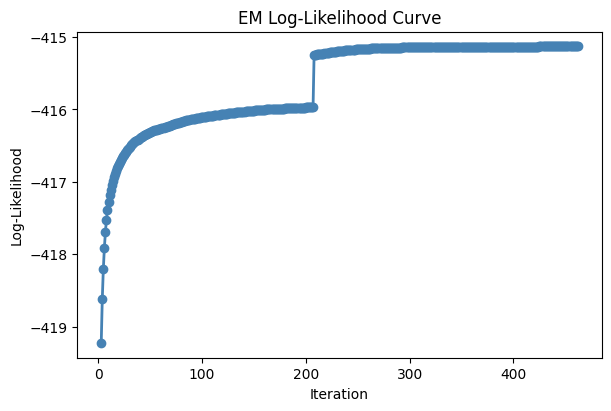

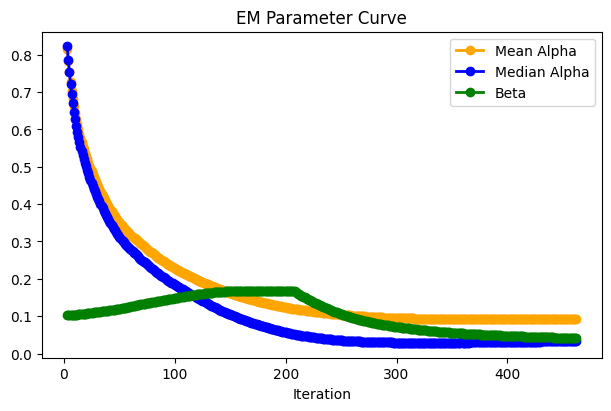

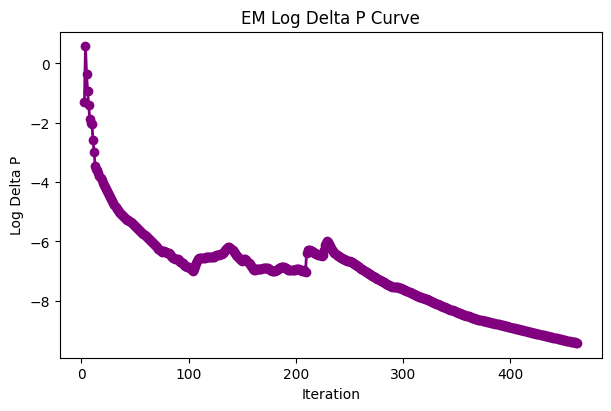

In [11]:
# plot cellsweep likelihood over epochs
if os.path.exists(cellsweep_log_file):
    cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=cellsweep_log_file, show=True)
    cs_utils.plot_cellsweep_parameters_over_epochs(log_path=cellsweep_log_file, show=True)
    cs_utils.plot_cellsweep_delta_p_over_epochs(log_path=cellsweep_log_file, show=True)

# # plot ambient_hat vs empty fraction
# cs_utils.plot_ambient_hat_vs_empty_fraction(adata_raw, adata_cellsweep, remove_zeroes=True, lower_quantile_removed=None, upper_quantile_removed=0.99, out_path=os.path.join(out_dir, "cellsweep_ambient_hat_vs_empty_fraction.png"))

# # plot knee plot colored by alpha_hat
# adata_denoised = adata_cellsweep.copy()
# adata_denoised.layers["denoised"] = adata_denoised.X.copy()
# adata_denoised.X = adata_denoised.layers["raw"].copy()
# cs_utils.knee_plot(adata_denoised, expected_cells=expected_cells, color_column="alpha_hat")
# cs_utils.knee_plot(adata_denoised[~adata_denoised.obs["is_empty"]], expected_cells=expected_cells, color_column="alpha_hat")
# adata_denoised.obs["total_counts_raw"] = np.ravel(adata_denoised.layers["raw"].sum(axis=1))
# adata_denoised.obs["total_counts_denoised"] = np.ravel(adata_denoised.layers["denoised"].sum(axis=1))
# adata_denoised.obs.loc[~adata_denoised.obs["is_empty"]].head(50)

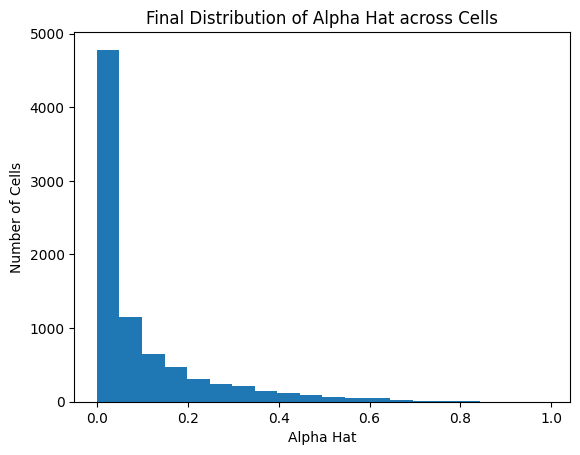

In [12]:
plt.figure()
plt.hist(adata_cellsweep.obs['alpha_hat'], bins=20)
plt.xlabel('Alpha Hat')
plt.ylabel('Number of Cells')
plt.title('Final Distribution of Alpha Hat across Cells')
plt.show()

In [13]:
adata_cellsweep.obs['alpha_hat'].describe()

count     8.381000e+03
mean      9.205518e-02
std       1.362999e-01
min      1.173515e-118
25%       6.569057e-04
50%       3.354270e-02
75%       1.227776e-01
max       9.925480e-01
Name: alpha_hat, dtype: float64

In [14]:
(adata_cellsweep.obs['alpha_hat'] > 0.5).sum()

np.int64(216)

## CellBender (v0.3.0)

In [15]:
%%time
if "cellbender" in alternative_tools and (not os.path.exists(adata_path_cellbender_filtered) or overwrite):
     if rerun_tools or cellbender_matrix_filtered_url is None:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellsweep_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          ckpt_out_path = cellbender_ckpt.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 73 μs, sys: 4 μs, total: 77 μs
Wall time: 68.7 μs


In [16]:
adata_cellbender = None
if "cellbender" in alternative_tools:
    adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
    adata_cellbender.var_names_make_unique()
    print(f"Counts are less than or equal check for CellBender: {cs_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [17]:
# %%time
if "soupx" in alternative_tools and (soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite)):
    if rerun_tools or soupx_matrix_url is None:
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cs_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellsweep_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                leiden
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

In [18]:
adata_soupx = None
if "soupx" in alternative_tools:
    adata_soupx = cs_utils.load_adata(soupx_out_prefix)
    adata_soupx.var_names_make_unique()
    print(f"Counts are less than or equal check for SoupX: {cs_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [19]:
%%time
if "decontx" in alternative_tools and (decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite)):
    if rerun_tools or decontx_matrix_url is None:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 0 ns, sys: 35 μs, total: 35 μs
Wall time: 43.6 μs


In [20]:
adata_decontx = None
if "decontx" in alternative_tools:
    adata_decontx = cs_utils.load_adata(decontx_out_prefix)
    adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
    adata_decontx.var_names_make_unique()
    print(f"Counts are less than or equal check for DecontX: {cs_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [21]:
%%time
%env MPLBACKEND=
if "scar" in alternative_tools and (adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite)):
     if rerun_tools or scar_matrix_url is None:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellsweep_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            -p {scar_prob} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

env: MPLBACKEND=
CPU times: user 794 μs, sys: 0 ns, total: 794 μs
Wall time: 757 μs


In [22]:
adata_scar = None
if "scar" in alternative_tools:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cs_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for scAR: False


# Analysis

In [23]:
adata_dict = OrderedDict(
    raw=adata_raw,
    cellsweep=adata_cellsweep,
    cellbender=adata_cellbender,
    soupx=adata_soupx,
    decontx=adata_decontx,
    scar=adata_scar
)

for key, adata in adata_dict.items():
    if adata is None:
        continue
    print(f"{key}:\n{adata}\n\n")

raw:
AnnData object with n_obs × n_vars = 737280 × 33694
    obs: 'is_empty'
    var: 'gene_ids', 'empty_counts'


cellsweep:
AnnData object with n_obs × n_vars = 8381 × 33694
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat'
    layers: 'raw'


cellbender:
AnnData object with n_obs × n_vars = 8816 × 33694
    var: 'gene_ids', 'feature_types', 'genome'


soupx:
AnnData object with n_obs × n_vars = 8381 × 33694


decontx:
AnnData object with n_obs × n_vars = 8381 × 33694


scar:
AnnData object with n_obs × n_vars = 8381 × 33694
    var: 'gene_ids', 'feature_types'
    uns: 'ambient_profile_Gene Expression', 'ambient_profile_all'
    layers: 'raw'




### Total counts removed

In [24]:
for key, adata in adata_dict.items():
    if key == "raw" or adata is None:
        continue
    adata_raw_tmp, adata = cs_utils.take_adata_cell_gene_intersection(adata_raw, adata)

    counts_removed_matrix = adata_raw_tmp.X - adata.X
    counts_removed_matrix[counts_removed_matrix < 0] = 0  # zero out negative values
    total_counts_removed = counts_removed_matrix.sum()
    # print with commas
    print(f"Total counts removed by {key}: {total_counts_removed:,}")

    counts_added_matrix = adata.X - adata_raw_tmp.X
    counts_added_matrix[counts_added_matrix < 0] = 0  # zero out negative values
    total_counts_added = counts_added_matrix.sum()
    print(f"Total counts added by {key}: {total_counts_added:,}")

    # calculated mean and median counts removed per cell
    counts_removed_per_cell = np.ravel(counts_removed_matrix.sum(axis=1))
    mean_counts_removed_per_cell = np.mean(counts_removed_per_cell)
    median_counts_removed_per_cell = np.median(counts_removed_per_cell)
    print(f"Mean counts removed per cell by {key}: {mean_counts_removed_per_cell:,.2f}")
    print(f"Median counts removed per cell by {key}: {median_counts_removed_per_cell:,.2f}")

    # count fraction of cells with more than 10 counts removed
    count_removed_thresholds = [10, 50, 100, 1000]
    for count_removed_threshold in count_removed_thresholds:
        num_cells_more_than_n_removed = np.sum(counts_removed_per_cell > count_removed_threshold)
        fraction_cells_more_than_n_removed = num_cells_more_than_n_removed / adata.n_obs
        print(f"Fraction of cells with more than {count_removed_threshold} counts removed by {key}: {fraction_cells_more_than_n_removed:.3f}")
    
    print("----------------------------\n")

Total counts removed by cellsweep: 5,597,472.5
Total counts added by cellsweep: 0.0
Mean counts removed per cell by cellsweep: 667.88
Median counts removed per cell by cellsweep: 299.28
Fraction of cells with more than 10 counts removed by cellsweep: 1.000
Fraction of cells with more than 50 counts removed by cellsweep: 1.000
Fraction of cells with more than 100 counts removed by cellsweep: 0.974
Fraction of cells with more than 1000 counts removed by cellsweep: 0.178
----------------------------

Total counts removed by cellbender: 1,069,253.0
Total counts added by cellbender: 0.0
Mean counts removed per cell by cellbender: 121.29
Median counts removed per cell by cellbender: 104.00
Fraction of cells with more than 10 counts removed by cellbender: 1.000
Fraction of cells with more than 50 counts removed by cellbender: 0.974
Fraction of cells with more than 100 counts removed by cellbender: 0.545
Fraction of cells with more than 1000 counts removed by cellbender: 0.000
----------------

## Simulations

In [25]:
if dataset_name.startswith("simulation"):

    def get_top_contaminated_markers(adata, n_top):
        marker_sets = adata.uns["marker_sets"]

        # mask for real cells only
        cell_mask = ~adata.obs["is_empty"].values
        X_noise = adata.layers["noise"][cell_mask].toarray()
        X_real  = adata.layers["real"][cell_mask].toarray()

        # --- collect contamination for all markers globally ---
        marker_info = []  # (gene, cell_type, contamination)

        for i, markers in enumerate(marker_sets):
            cell_type = f"Type_{i}"
            for g in markers:
                noise_sum = X_noise[:, g].sum()
                real_sum  = X_real[:, g].sum()
                total = noise_sum + real_sum

                if total == 0:
                    contamination = 0.0
                else:
                    contamination = noise_sum / total

                marker_info.append((g, cell_type, contamination))

        # --- sort globally by contamination ---
        marker_info.sort(key=lambda x: x[2], reverse=True)

        # --- select top-N globally ---
        top_markers = marker_info[:n_top]

        markers = []
        # --- regroup by cell type ---
        result = defaultdict(list)
        for g, cell_type, _ in top_markers:
            markers.append(g)
            result[cell_type].append(f"Gene_{g}")

        return dict(result), markers

    marker_mat = adata_dict["raw"].uns["marker_sets"]
    markers = marker_mat.flatten().tolist()
    marker_genes, _ = get_top_contaminated_markers(adata_dict["raw"], n_top=20)

    cell_sets = [
        set(adata.obs_names)
        for key, adata in adata_dict.items()
        if adata is not None and key != "raw"
    ]
    cells_common_to_all_tools = set.intersection(*cell_sets)

    for adata_name, adata in adata_dict.items():
        if adata_name == "raw" or adata is None:
            continue

        adata = adata.copy()
        adata = adata[adata.obs_names.isin(cells_common_to_all_tools)].copy()
        cs_utils.evaluate_simulation_denoising(adata_processed = adata, adata_real = adata_dict["raw"].copy(), tool = adata_name, out_base = f"{out_dir}/{adata_name}_denoising_evaluation", show=True)

        adata_predicted_signal = adata.copy()
        adata_raw_tmp = adata_dict["raw"].copy()
        adata_predicted_signal, adata_raw_tmp = cs_utils.take_adata_cell_gene_intersection(adata_predicted_signal, adata_raw_tmp)

        adata_predicted_noise = adata_predicted_signal.copy()
        adata_predicted_noise.X = adata_raw_tmp.X - adata_predicted_signal.X  # noise = raw - signal
        
        adata_true_noise = adata_raw_tmp.copy()
        adata_true_noise.X = adata_raw_tmp.layers["noise"].copy()  # true noise

        adata_true_signal = adata_raw_tmp.copy()
        adata_true_signal.X = adata_raw_tmp.layers["real"].copy()

        show = (adata_name == "cellsweep")
        
        # noise plots
        density_type_matrix = "scatter_with_kde" if adata_predicted_noise.X.size < 1e6 else "scatter_with_density"
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="matrix", density_type=density_type_matrix, scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted matrix noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_matrix_expression_scatterplot.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted cell noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_cell_expression_scatterplot.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted gene noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_gene_expression_scatterplot.png"), show=show)

        # signal-noise plots
        def plot_signal_noise_scatter(adata_true_signal, adata_predicted_signal, adata_true_noise, adata_predicted_noise):
            X_true = adata_true_signal.X
            X_noise = adata_predicted_noise.X
            X_true_noise = adata_true_noise.X

            noise_diff = np.asarray((X_true_noise - X_noise).toarray()) if sp.issparse(X_true_noise) else (X_true_noise - X_noise)
            total_noise = np.maximum(noise_diff, 0).sum(axis=1)

            X_signal = X_true + np.minimum(np.asarray(noise_diff), 0)
            adata_signal_tmp = ad.AnnData(
                X=X_signal,
                obs=adata_predicted_signal.obs.copy(),
                var=adata_predicted_signal.var.copy()
            )
            if sp.issparse(adata_signal_tmp.X):
                total_signal = np.asarray(adata_signal_tmp.X.sum(axis=1)).ravel()
            else:
                total_signal = adata_signal_tmp.X.sum(axis=1)
        
            # cs_utils.plot_histogram_simulation(X_true_noise, data_type="matrix", log_scale=True, title="True noise")
            # cs_utils.plot_histogram_simulation(X_true_noise, data_type="cell", log_scale=False, title="True noise")
            cs_utils.plot_histogram_simulation(noise_diff, data_type="matrix", log_scale=True, title="Noise difference (true - predicted)")

            adata_predicted_signal.obs["total_signal"] = total_signal
            adata_predicted_signal.obs["total_noise"] = total_noise

            adata_raw_tmp.obs["total_noise"] = np.asarray(X_true_noise.sum(axis=1)).ravel() 
            adata_raw_tmp.obs["total_signal"] = np.asarray(X_true.sum(axis=1)).ravel() 

            out_path = os.path.join(out_dir, f"cross_species_joint_scatterplot_total_signal_vs_total_noise_{adata_name}.png")
            cs_utils.plot_cross_species_joint_scatterplot(adata_raw_tmp, adata_predicted_signal, processed_name=adata_name, x_name="total_signal", y_name="total_noise", genome_column=None, marginal_color_number=2, x_axis="total_signal", y_axis="total_noise", marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=out_path, show=True)
            
        
        plot_signal_noise_scatter(adata_true_signal, adata_predicted_signal, adata_true_noise, adata_predicted_noise)
        plot_signal_noise_scatter(adata_true_signal[:, markers].copy(), adata_predicted_signal[:, markers].copy(), adata_true_noise[:, markers].copy(), adata_predicted_noise[:, markers].copy())

        if "celltype" not in adata_predicted_signal.obs.columns:
            adata_predicted_signal.obs = adata_predicted_signal.obs.merge(adata_raw_tmp.obs[["celltype"]], left_index=True, right_index=True, how="left")

        out_path_raw = os.path.join(out_dir, f"dotplot_raw.png")
        out_path_processed = os.path.join(out_dir, f"dotplot_{adata_name}.png")
        plot_raw = (adata_name == "cellsweep")
        cs_utils.make_raw_and_processed_dotplots(adata_raw_tmp, adata_predicted_signal, marker_genes, plot_raw=plot_raw, cluster_column='celltype', log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot", title_processed=f"{adata_name} Processed Data Dotplot", out_path_raw=out_path_raw, out_path_processed=out_path_processed)

        # del adata_raw_tmp
        # del adata_predicted_signal
        # del adata_predicted_noise
        # del adata_true_signal
        # del adata_true_noise

## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  style

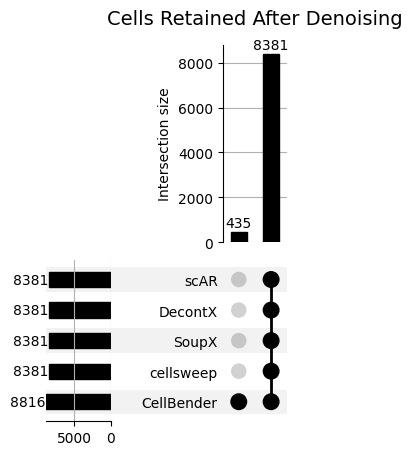

In [26]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellsweep": set(adata_cellsweep.obs_names),
    "CellBender": set(adata_cellbender.obs_names) if adata_cellbender is not None else None,
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cs_utils.make_upset_plot(upset_data_dict, title="Cells Retained After Denoising", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Raw vs processed scatterplots

1/15 Comparing raw vs cellsweep...
Per-cell Spearman correlation between raw and cellsweep:
  Mean: 0.9880
  Median: 0.9999
  Std: 0.0567
  Min: 0.6787
  Max: 1.0000


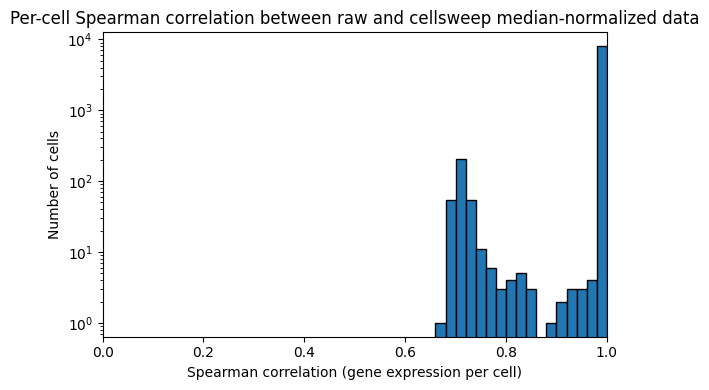

Per-cell Spearman correlation between raw and cellsweep:
  Mean: 0.9880
  Median: 0.9999
  Std: 0.0567
  Min: 0.6787
  Max: 1.0000


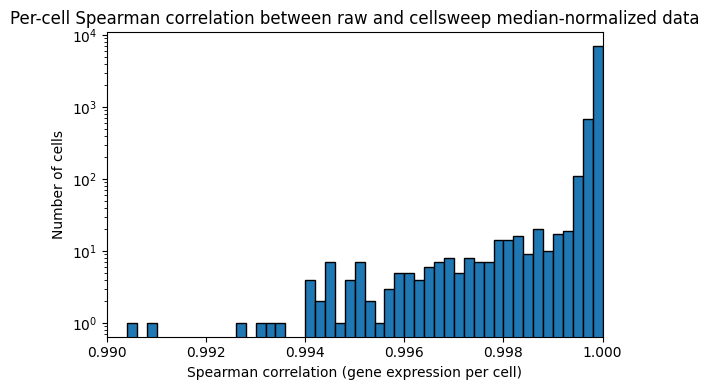

In [ ]:
adata_dict_nonempty_length = len([adata for adata in adata_dict.values() if adata is not None])
num_iterations = adata_dict_nonempty_length * (adata_dict_nonempty_length - 1) // 2  # n choose 2
iteration = 1
for (key1, val1), (key2, val2) in itertools.combinations(adata_dict.items(), 2):
    if val1 is None or val2 is None:
        continue

    print(f"{iteration}/{num_iterations} Comparing {key1} vs {key2}...")
    show = (key1 in {"raw", "cellsweep", "cellbender"} and key2 in {"raw", "cellsweep", "cellbender"})

    # if "raw" not in {key1, key2}:
    #     continue

    if "raw" not in {key1, key2} and "cellsweep" not in {key1, key2}:
        continue

    val1, val2 = val1.copy(), val2.copy()
    
    # Scatterplot by matrix, cell, and gene
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_matrix_expression_scatterplot.png"), show=show)
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_cell_expression_scatterplot.png"), show=show)
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_gene_expression_scatterplot.png"), show=show)
    
    # # Histogram of differences from raw by matrix, cell, and gene
    # cs_utils.plot_per_cell_difference(val1, val2, plot_type="matrix", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_matrix_absolute_difference_from_{key1}.png"))
    # cs_utils.plot_per_cell_difference(val1, val2, plot_type="cell", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_cell_absolute_difference_from_{key1}.png"), show=show)
    # cs_utils.plot_per_cell_difference(val1, val2, plot_type="gene", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_gene_absolute_difference_from_{key1}.png"), show=show)

    # # Histogram of cosine similarity by cell and gene
    # cs_utils.plot_per_cell_correlation(val1, val2, plot_type="cell", title=f"Per-Cell Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_cell_correlation.png"), show=show)
    # cs_utils.plot_per_cell_correlation(val1, val2, plot_type="gene", title=f"Per-Gene Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_gene_correlation.png"), show=show)
    
    # Histogram of spearman correlation per cell
    cs_utils.plot_cell_spearman_histogram(val1, val2, raw_name=key1, processed_name=key2, xlim=(0,1), out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_spearman_histogram.png"), show=True)
    cs_utils.plot_cell_spearman_histogram(val1, val2, raw_name=key1, processed_name=key2, xlim=(0.99,1), out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_spearman_histogram_099.png"), show=True)
    # cs_utils.plot_cell_spearman_histogram(val1, val2, raw_name=key1, processed_name=key2, metric="rbo", rbo_p=0.9, xlim=(0,1), out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_rbo_histogram.png"), show=True)

    # # Spearman correlation after normalizing by median gene expression
    # val1 = cs_utils.normalize_by_median_gene_expression(val1)
    # val2 = cs_utils.normalize_by_median_gene_expression(val2)
    # cs_utils.plot_cell_spearman_histogram(val1, val2, raw_name=key1, processed_name=key2, xlim=(0,1), title = f"Per-cell Spearman correlation between {key1} and {key2} median-normalized data", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_spearman_histogram_median_normalized.png"), show=True)
    # cs_utils.plot_cell_spearman_histogram(val1, val2, raw_name=key1, processed_name=key2, xlim=(0.99,1), title = f"Per-cell Spearman correlation between {key1} and {key2} median-normalized data", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_spearman_histogram_099_median_normalized.png"), show=True)
    # # cs_utils.plot_cell_spearman_histogram(val1, val2, raw_name=key1, processed_name=key2, metric="rbo", rbo_p=0.9, xlim=(0,1), title = f"Per-cell RBO (p=0.9) correlation between {key1} and {key2} median-normalized data", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_rbo_histogram_median_normalized.png"), show=True)
    
    iteration += 1

In [ ]:
if dataset_name.startswith("simulation"):
    sys.exit()

## Joint scatterplot of human vs. mouse counts (hgmm12k dataset only)

Contamination stats for raw:
Mean human contamination counts (mouse reads in human cells): 1.25%
Mean mouse contamination counts (human reads in mouse cells): 2.93%
95th percentile human contamination counts (mouse reads in human cells): 2.02%
95th percentile mouse contamination counts (human reads in mouse cells): 4.46%
Total contamination across all human cells: 1,370,820
Total contamination across all mouse cells: 1,853,584
Total signal across all human cells: 116,140,240
Total signal across all mouse cells: 64,925,760
-----
Contamination stats for cellsweep:
Mean human contamination counts (mouse reads in human cells): 0.02%
Mean mouse contamination counts (human reads in mouse cells): 0.03%
95th percentile human contamination counts (mouse reads in human cells): 0.03%
95th percentile mouse contamination counts (human reads in mouse cells): 0.06%
Total contamination across all human cells: 19,328
Total contamination across all mouse cells: 21,468
Total signal across all human cells

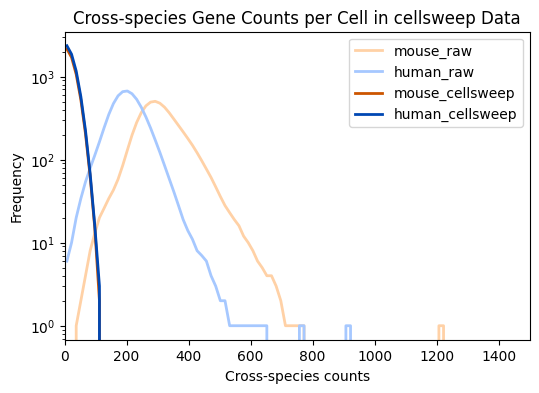

Marginal distribution stats:
                       x_mean      x_median        y_mean      y_median
group                                                                  
human_cellsweep  18120.365234  17481.266602      4.081635      3.810627
human_raw        18518.257812  17868.500000    219.561859    201.000000
mouse_cellsweep      4.736153      4.429923  11126.688477  10442.287109
mouse_raw          323.586853    303.000000  11300.296875  10607.500000
Contamination stats for cellbender:
Mean human contamination counts (mouse reads in human cells): 0.06%
Mean mouse contamination counts (human reads in mouse cells): 0.06%
95th percentile human contamination counts (mouse reads in human cells): 0.04%
95th percentile mouse contamination counts (human reads in mouse cells): 0.10%
Total contamination across all human cells: 86,770
Total contamination across all mouse cells: 54,246
Total signal across all human cells: 115,836,817
Total signal across all mouse cells: 64,884,898
Human cell

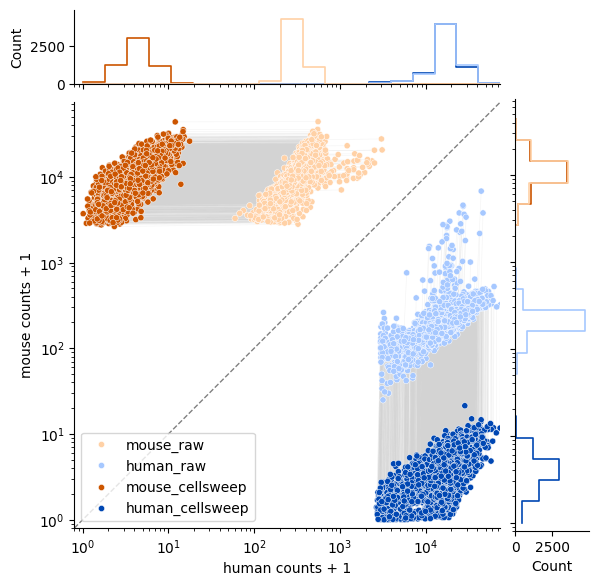

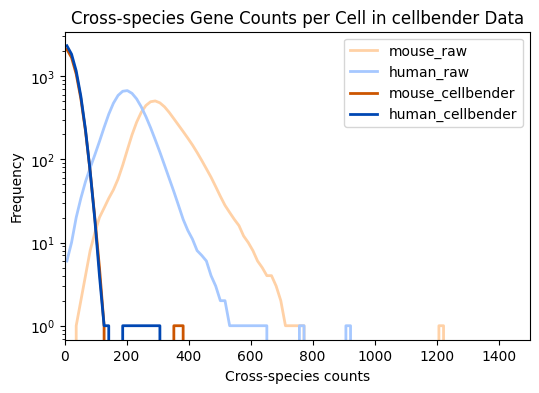

Marginal distribution stats:
                        x_mean  x_median        y_mean  y_median
group                                                           
human_cellbender  18343.828125   17710.5     14.807079       3.0
human_raw         18518.257812   17868.5    219.561862     201.0
mouse_cellbender     10.432127       3.0  11195.964323   10507.0
mouse_raw           323.586843     303.0  11300.296728   10607.5
Contamination stats for soupx:
Mean human contamination counts (mouse reads in human cells): 0.21%
Mean mouse contamination counts (human reads in mouse cells): 1.22%
95th percentile human contamination counts (mouse reads in human cells): 0.50%
95th percentile mouse contamination counts (human reads in mouse cells): 2.54%
Total contamination across all human cells: 190,509
Total contamination across all mouse cells: 668,161
Total signal across all human cells: 113,798,282
Total signal across all mouse cells: 64,134,680
Human cell contamination removed: 1,180,311 (86.10% of 

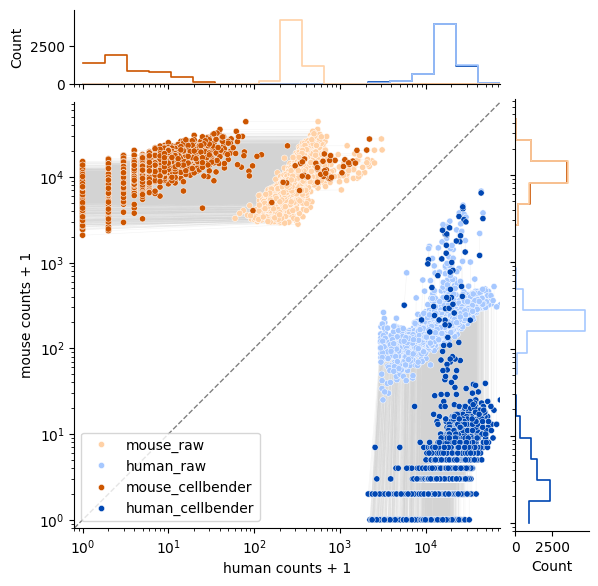

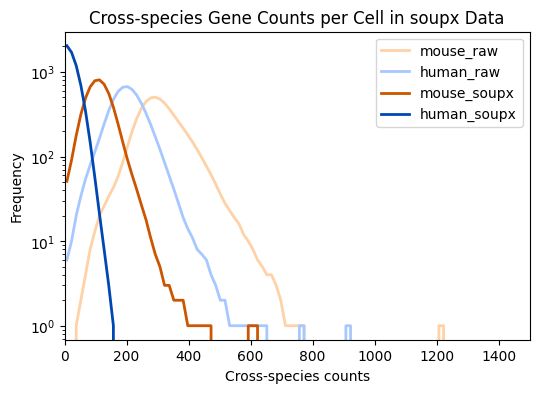

Marginal distribution stats:
                   x_mean      x_median        y_mean      y_median
group                                                              
human_raw    18518.257812  17868.500000    219.561862    201.000000
human_soupx  18144.858722  17512.608372     31.374461     14.469992
mouse_raw      323.586843    303.000000  11300.296728  10607.500000
mouse_soupx    117.282731    110.605159  11162.621990  10479.772774
Contamination stats for decontx:
Mean human contamination counts (mouse reads in human cells): 0.45%
Mean mouse contamination counts (human reads in mouse cells): 0.98%
95th percentile human contamination counts (mouse reads in human cells): 0.29%
95th percentile mouse contamination counts (human reads in mouse cells): 0.98%
Total contamination across all human cells: 291,793
Total contamination across all mouse cells: 636,128
Total signal across all human cells: 113,432,443
Total signal across all mouse cells: 64,270,337
Human cell contamination removed: 1

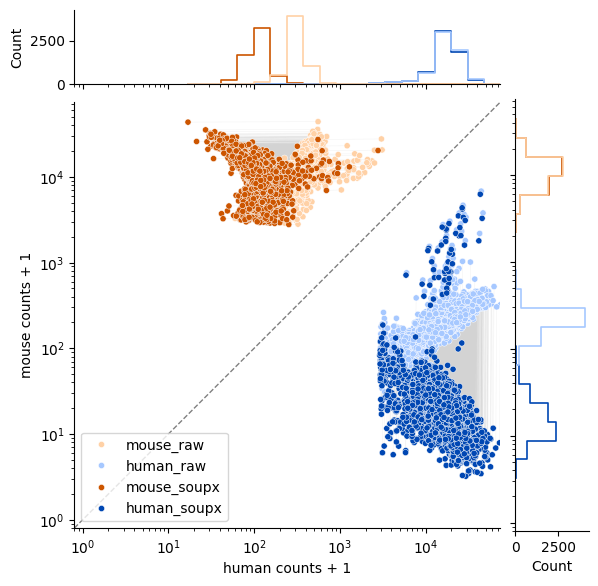

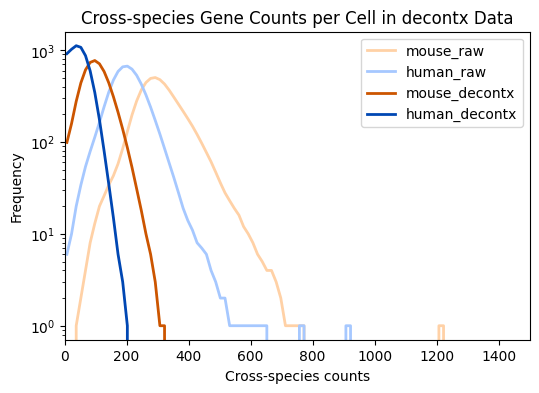

Marginal distribution stats:
                     x_mean      x_median        y_mean      y_median
group                                                                
human_decontx  18086.529858  17516.624856     47.523058     44.771797
human_raw      18518.257812  17868.500000    219.561862    201.000000
mouse_decontx    111.707909     98.697591  11186.230986  10497.229867
mouse_raw        323.586843    303.000000  11300.296728  10607.500000
Contamination stats for scar:
Mean human contamination counts (mouse reads in human cells): 0.02%
Mean mouse contamination counts (human reads in mouse cells): 0.04%
95th percentile human contamination counts (mouse reads in human cells): 0.02%
95th percentile mouse contamination counts (human reads in mouse cells): 0.03%
Total contamination across all human cells: 17,667
Total contamination across all mouse cells: 22,817
Total signal across all human cells: 113,113,935
Total signal across all mouse cells: 63,455,805
Human cell contamination rem

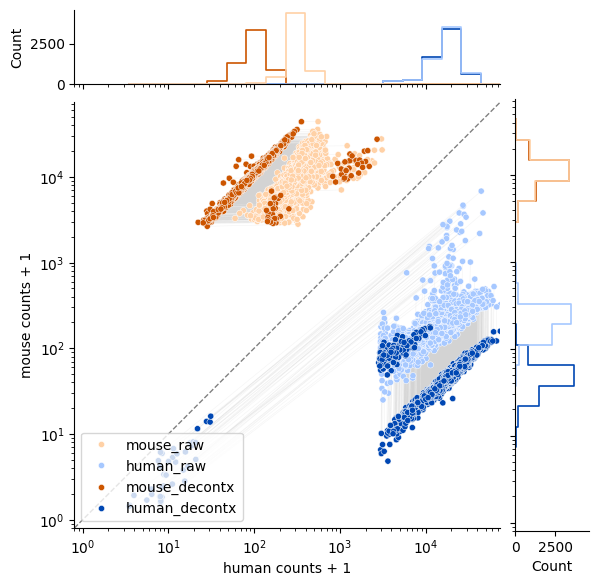

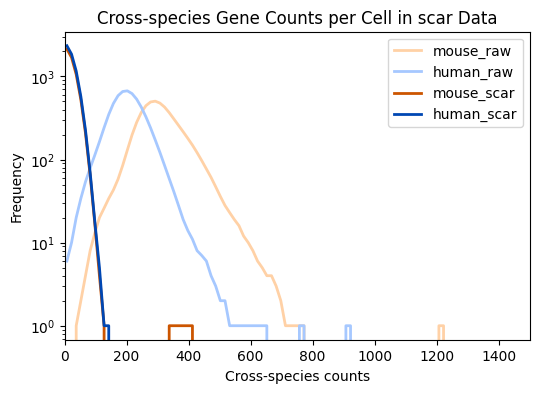

Marginal distribution stats:
                  x_mean  x_median        y_mean  y_median
group                                                     
human_raw   18518.257812   17868.5    219.561862     201.0
human_scar  18035.747290   17421.0      3.816805       2.0
mouse_raw     323.586843     303.0  11300.296728   10607.5
mouse_scar      4.970936       1.0  11044.474591   10355.0


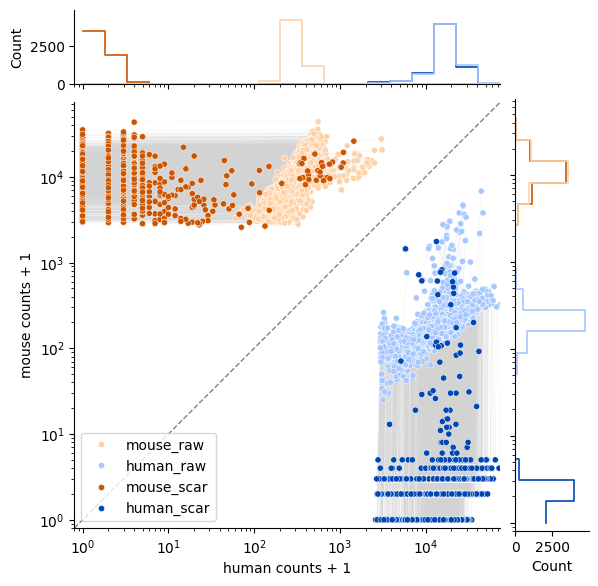

In [ ]:
if dataset_name == "hgmm_12k" or dataset_name == "ATAC_hgmm_10k":
    cell_sets = [
        set(adata.obs_names)
        for key, adata in adata_dict.items()
        if adata is not None and key != "raw"
    ]
    cells_common_to_all_tools = set.intersection(*cell_sets)
    
    if "genome" not in adata_raw.obs.columns:
        adata_raw = cs_utils.identify_human_and_mouse_cells(adata_raw, human_prefix = "hg19_", mouse_prefix = "mm10_")
    
    doublet_cell_set = set(adata_raw.obs.index[adata_raw.obs["is_doublet"]])
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()

    def print_contamination_stats(adata, doublet_cell_set=None, raw_mouse_cell_contamination=None, raw_human_cell_contamination=None, raw_mouse_cell_signal=None, raw_human_cell_signal=None):
        adata = adata.copy()
        if "is_empty" in adata.obs.columns:
            adata = adata[~adata.obs["is_empty"]].copy()
        if doublet_cell_set is not None:
            adata = adata[~adata.obs_names.isin(doublet_cell_set)].copy()
        if "genome" not in adata.obs.columns or "human_counts_total" not in adata.obs.columns or "mouse_counts_total" not in adata.obs.columns:
            adata = cs_utils.identify_human_and_mouse_cells(adata)  # adds human_counts_total, mouse_counts_total, genome to adata.obs
        adata.obs["total_counts"] = np.ravel(adata.X.sum(axis=1))
        adata.obs.loc[adata.obs["genome"] == "hg19", "fraction_contamination"] = adata.obs["mouse_counts_total"] / adata.obs["total_counts"]
        adata.obs.loc[adata.obs["genome"] == "mm10", "fraction_contamination"] = adata.obs["human_counts_total"] / adata.obs["total_counts"]

        mean_human_contamination_counts = adata.obs.loc[adata.obs["genome"] == "hg19", "fraction_contamination"].mean()
        mean_mouse_contamination_counts = adata.obs.loc[adata.obs["genome"] == "mm10", "fraction_contamination"].mean()

        # get 95th percentile
        human_contamination_counts_95th = adata.obs.loc[adata.obs["genome"] == "hg19", "fraction_contamination"].quantile(0.95)
        mouse_contamination_counts_95th = adata.obs.loc[adata.obs["genome"] == "mm10", "fraction_contamination"].quantile(0.95)

        human_cell_contamination = adata.obs.loc[adata.obs["genome"] == "hg19", "mouse_counts_total"].sum()
        mouse_cell_contamination = adata.obs.loc[adata.obs["genome"] == "mm10", "human_counts_total"].sum()
        human_cell_signal = adata.obs.loc[adata.obs["genome"] == "hg19", "human_counts_total"].sum()
        mouse_cell_signal = adata.obs.loc[adata.obs["genome"] == "mm10", "mouse_counts_total"].sum()

        # print as percentage rounded to 4 decimal places
        print(f"Mean human contamination counts (mouse reads in human cells): {mean_human_contamination_counts:.2%}")
        print(f"Mean mouse contamination counts (human reads in mouse cells): {mean_mouse_contamination_counts:.2%}")
        print(f"95th percentile human contamination counts (mouse reads in human cells): {human_contamination_counts_95th:.2%}")
        print(f"95th percentile mouse contamination counts (human reads in mouse cells): {mouse_contamination_counts_95th:.2%}")
        print(f"Total contamination across all human cells: {human_cell_contamination:,.0f}")
        print(f"Total contamination across all mouse cells: {mouse_cell_contamination:,.0f}")
        print(f"Total signal across all human cells: {human_cell_signal:,.0f}")
        print(f"Total signal across all mouse cells: {mouse_cell_signal:,.0f}")
        if raw_human_cell_contamination is not None and raw_mouse_cell_contamination is not None:
            human_contamination_removed = raw_human_cell_contamination - human_cell_contamination
            mouse_contamination_removed = raw_mouse_cell_contamination - mouse_cell_contamination
            print(f"Human cell contamination removed: {human_contamination_removed:,.0f} ({human_contamination_removed / raw_human_cell_contamination:.2%} of raw)")
            print(f"Mouse cell contamination removed: {mouse_contamination_removed:,.0f} ({mouse_contamination_removed / raw_mouse_cell_contamination:.2%} of raw)")
        if raw_human_cell_signal is not None and raw_mouse_cell_signal is not None:
            print(f"Human cell signal remaining: {human_cell_signal:,.0f} ({human_cell_signal / raw_human_cell_signal:.2%} of raw)")
            print(f"Mouse cell signal remaining: {mouse_cell_signal:,.0f} ({mouse_cell_signal / raw_mouse_cell_signal:.2%} of raw)")

        print("-----")

        return human_cell_contamination, mouse_cell_contamination, human_cell_signal, mouse_cell_signal

    raw_human_cell_contamination, raw_mouse_cell_contamination, raw_human_cell_signal, raw_mouse_cell_signal = None, None, None, None
    for key, adata_processed in adata_dict.items():
        print(f"Contamination stats for {key}:")
        human_cell_contamination, mouse_cell_contamination, human_cell_signal, mouse_cell_signal = print_contamination_stats(adata_processed, doublet_cell_set=doublet_cell_set, raw_human_cell_contamination=raw_human_cell_contamination, raw_mouse_cell_contamination=raw_mouse_cell_contamination, raw_human_cell_signal=raw_human_cell_signal, raw_mouse_cell_signal=raw_mouse_cell_signal)
        if key == "raw":
            raw_human_cell_contamination = human_cell_contamination
            raw_mouse_cell_contamination = mouse_cell_contamination
            raw_human_cell_signal = human_cell_signal
            raw_mouse_cell_signal = mouse_cell_signal

        if key == "raw" or adata_processed is None:
            continue

        adata_processed = adata_processed.copy()

        # add genome info to processed adata from raw
        if "genome" not in adata_processed.obs.columns:
            adata_processed.obs["genome"] = adata_raw.obs["genome"].reindex(adata_processed.obs_names)
            adata_dict[key] = adata_processed
        
        adata_processed = adata_processed[adata_processed.obs_names.isin(cells_common_to_all_tools)].copy()

        # plot histograms of human and mouse contamination
        cs_utils.plot_cross_species_histogram(adata_processed, adata_raw=adata_raw, processed_name=key, doublet_cell_set=doublet_cell_set, xmax=1_500, kind="smooth", out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms_by_cells.png"))
        # cs_utils.plot_cross_species_histogram(adata_processed, adata_raw=adata_raw, processed_name=key, doublet_cell_set=doublet_cell_set, xmax=200, kind="smooth", plot_legend=False, title=None, out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms_by_cells_zoomed.png"))
        # cs_utils.plot_cross_species_histogram(adata_processed, adata_raw=adata_raw, processed_name=key, doublet_cell_set=doublet_cell_set, histogram_values="genes", xmax=35_000, out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms_by_genes.png"))

        cs_utils.plot_cross_species_joint_scatterplot(adata_raw_no_doublets, adata_processed, processed_name=key, marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{key}_joint_scatterplot.png"), show=True)

In [ ]:
if dataset_name == "hgmm_12k" or dataset_name == "ATAC_hgmm_10k":
    sys.exit()

## Alluvial plot of cluster differences

In [ ]:
adata_scanpy_dict = {}

for adata_name, adata in adata_dict.items():
    if adata is None:
        continue
    # elif adata_name == "raw":
    #     adata_scanpy_dict["raw"] = adata.copy()
    #     continue

    adata = adata.copy()
    filter_empty_droplets = True if adata_name == "raw" else False  # only filter empty droplets for raw data since other tools should have already done this
    adata = cs_utils.run_scanpy_preprocessing_and_clustering(adata, filter_empty_droplets=filter_empty_droplets, umi_cutoff=umi_cutoff, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata = cs_utils.determine_cell_types(adata, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
    adata.X = adata.layers["counts"].copy()  # reset X to raw counts
    adata_scanpy_dict[adata_name] = adata.copy()

17:06:54 - INFO - Adata initial shape: (737280, 33694)
17:06:54 - INFO - Filtering empty droplets using 'infer_empty_droplets' function with method 'threshold'. This is done by calculating the total UMI counts for each cell and removing those that fall below a certain threshold, which helps to eliminate empty droplets that do not contain any cells.
17:06:54 - INFO - After filtering empty droplets, adata shape: (8381, 33694)
17:06:54 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
17:06:54 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance a

In [ ]:
# wompwomp_path = os.path.join(os.path.dirname(cellsweep_dir), "wompwomp")
# wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"

# # wrap in try-except block to catch errors due to wompwomp installation issues
# try:
#     adatas_alluvial_dict = OrderedDict(
#         (name, adata)
#         for name, adata in adata_scanpy_dict.items()
#         if name != "raw" and adata is not None
#     )
#     adatas_alluvial = [adata for adata in adatas_alluvial_dict.values()]
#     col_names_alluvial = list(adatas_alluvial_dict.keys())
#     out_path = os.path.join(out_dir, "alluvial_cluster.png")
#     cs_utils.plot_alluvial(*adatas_alluvial, names=col_names_alluvial, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=out_path, verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
#     if os.path.exists(out_path):
#         display(Image(filename=out_path))

#     out_path = os.path.join(out_dir, "alluvial_celltype.png")
#     cs_utils.plot_alluvial(*adatas_alluvial, names=col_names_alluvial, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=out_path, verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
#     if os.path.exists(out_path):
#         display(Image(filename=out_path))

# except Exception as e:
#     print(f"Error generating alluvial plots with wompwomp: {e}")

## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# print(models.models_description())
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    if model_pkl == "Immune_All_High.pkl":
        celltype_mapping = CellBender_Fig2_to_Immune_All_High_celltype_mapping
        celltype_mapping_correlation = CellTypistHigh_to_ImmuneMajor
    elif model_pkl == "Immune_All_Low.pkl":
        celltype_mapping = CellBender_Fig2_to_Immune_All_Low_celltype_mapping
        celltype_mapping_correlation = CellTypistLow_to_ImmuneMajor
    else:
        raise ValueError(f"Unknown model_pkl {model_pkl} for pbmc8k dataset.")
    
    reverse_map = {fine: broad for broad, fine_list in celltype_mapping.items() for fine in fine_list}
    for adata_name, adata in adata_scanpy_dict.items():
        if adata_name == "raw" or adata is None:
            continue
        adata = adata.copy()
        adata.obs["broad_celltype"] = adata.obs["celltype"].astype(str).map(reverse_map).fillna("Other")
        adata.obs["celltype_for_correlation"] = adata.obs["celltype"].astype(str).map(celltype_mapping_correlation).fillna("Other")
        adata_scanpy_dict[adata_name] = adata  # update original dict with broad cell types

### Remake CellBender Figure 2

Raw Data Dotplot (raw clusters)


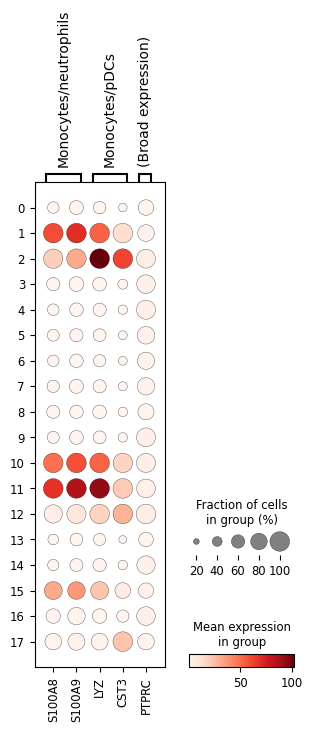

------------------------------
cellsweep Processed Data Dotplot (raw clusters)


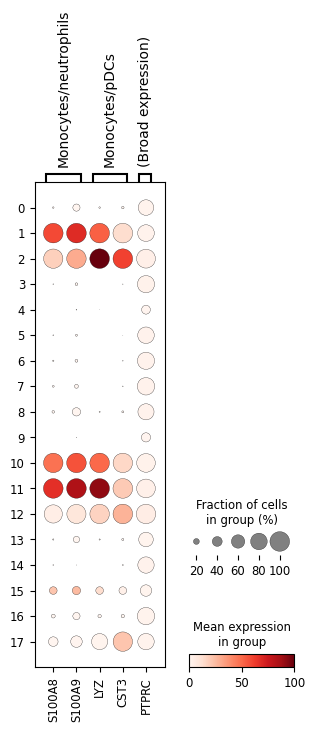

------------------------------


... storing 'feature_types' as categorical
... storing 'genome' as categorical


cellbender Processed Data Dotplot (raw clusters)


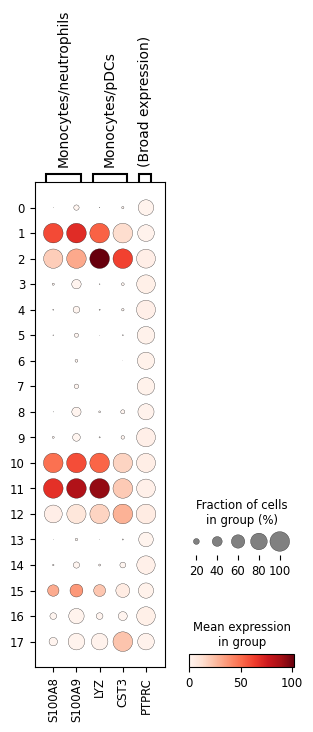

------------------------------
soupx Processed Data Dotplot (raw clusters)


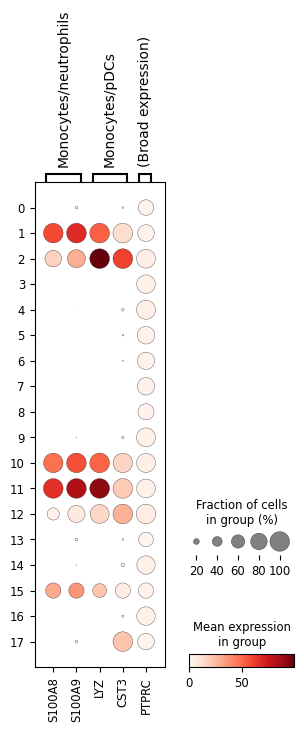

------------------------------
decontx Processed Data Dotplot (raw clusters)


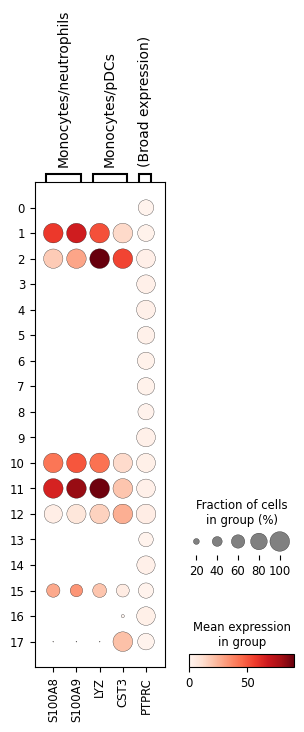

------------------------------
scar Processed Data Dotplot (raw clusters)


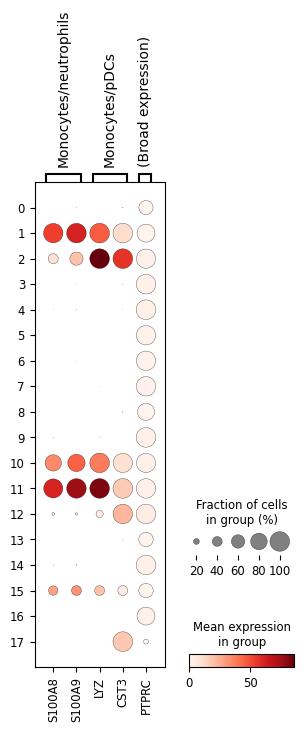

------------------------------


In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    marker_genes_cellbender_fig2 = cfg["marker_genes_cellbender_fig2"]
    if marker_genes_cellbender_fig2 is not None and len(marker_genes_cellbender_fig2) > 0:
        for adata_name, adata in adata_dict.items():
            if adata_name == "raw" or adata is None:
                continue
        
            adata = adata.copy()
        
            #* Standardize clusters to cellsweep
            adata.obs["leiden_raw"] = adata_scanpy_dict["raw"].obs["leiden"].reindex(adata.obs.index)
            adata = cs_utils.zero_out_low_counts(adata, threshold=0.5)  # zero out counts below 0.5

            plot_raw = (adata_name == "cellsweep")
            cs_utils.make_raw_and_processed_dotplots(adata_raw, adata, marker_genes_cellbender_fig2, plot_raw=plot_raw, cluster_column="leiden_raw", log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot (raw clusters)", title_processed=f"{adata_name} Processed Data Dotplot (raw clusters)", out_path_raw=os.path.join(out_dir, "dotplot_raw_with_raw_clusters_cellbender_fig2.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}_with_raw_clusters_cellbender_fig2.png"))

## Look only at the genes specific to monocytes: S100A8, S100A9, LYZ, CST3. Use PTPRC as a negative control.

In [ ]:
adata_raw_tmp = adata_raw_original[
    adata_processed.obs_names,  # align rows/cells to processed adata
    [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
].copy()

KeyError: "Values ['GACCTGGCACTTCTGC-1', 'GCTGCGACAAGCTGTT-1', 'CTGAAACTCACCACCT-1', 'AGATTGCGTTAGTGGG-1', 'ACATGGTCAGTCACTA-1', 'GCATGCGGTCTTCAAG-1', 'CTTTGCGCAGATGGCA-1', 'CTGCTGTTCTCGAGTA-1', 'CTGTTTATCTTGTCAT-1', 'AGTGTCACAGGAATCG-1', 'TACGGATAGAATAGGG-1', 'GTGTGCGCACGTAAGG-1', 'AGGGTGACAGTTCCCT-1', 'GTCGGGTCACCCATTC-1', 'AAAGCAATCACGATGT-1', 'CTCTACGTCCACTCCA-1', 'TACTTGTGTACGCACC-1', 'CTGTTTACATCCGTGG-1', 'GACTAACTCAACACAC-1', 'ACTTGTTAGCGTGAGT-1', 'TCCCGATTCAGCTGGC-1', 'GCGGGTTTCCCATTAT-1', 'CGTGTAACACGGTGTC-1', 'AAGGTTCAGTGCTGCC-1', 'CCTAAAGTCTTACCGC-1', 'AATCGGTAGGCGCTCT-1', 'TGGTTCCCATGTCGAT-1', 'GGGAGATAGGCAAAGA-1', 'TCGCGAGAGTAATCCC-1', 'TTGTAGGTCGGAAATA-1', 'TCGAGGCCAGACTCGC-1', 'TCTGGAATCTGGCGAC-1', 'GCTTCCATCGAATGGG-1', 'ACTGAACTCACCATAG-1', 'CGCGGTAAGAATCTCC-1', 'GATCGCGTCGTTTAGG-1', 'CTCGTACTCTTAGAGC-1', 'CGGTTAATCTTCTGGC-1', 'TGGCGCAGTCTCACCT-1', 'GGCTCGATCGTTTAGG-1', 'GACAGAGGTCAGTGGA-1', 'GTACTTTTCGCCAAAT-1', 'TGCGGGTCATTCTCAT-1', 'GCGCCAATCCCTCAGT-1', 'AGCGGTCCACTA

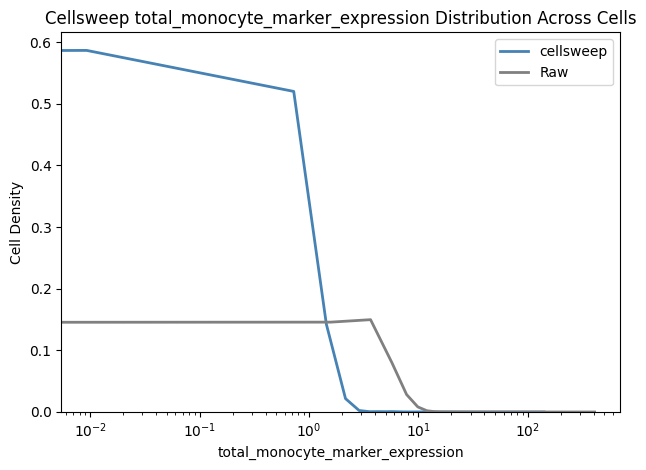

Creating scatterplot...
Calculating scatterplot...


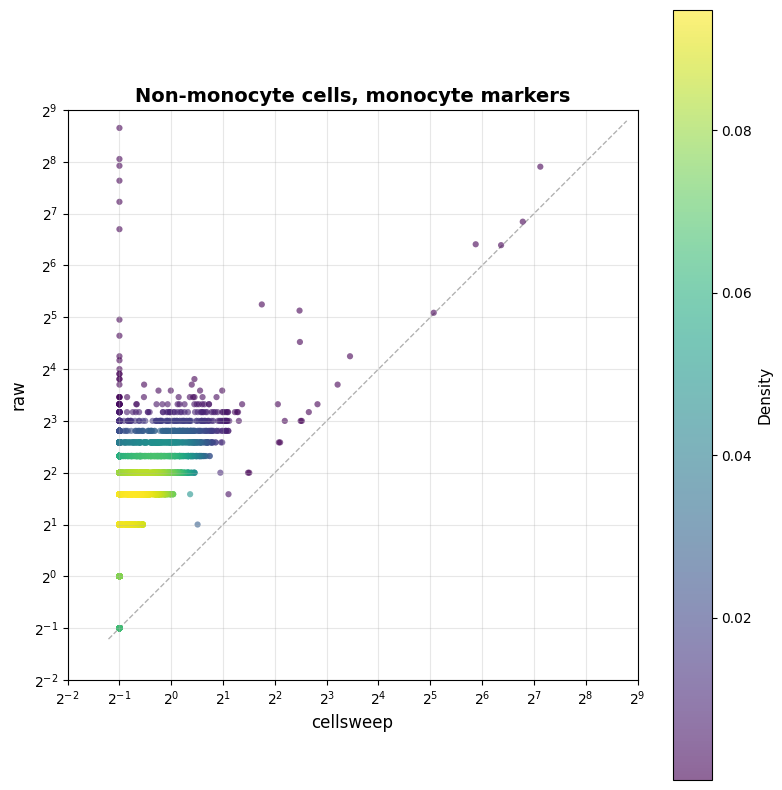

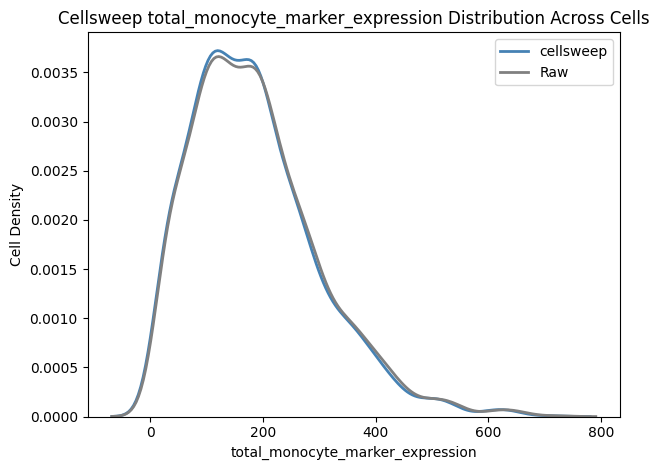

Creating scatterplot...
Calculating scatterplot...


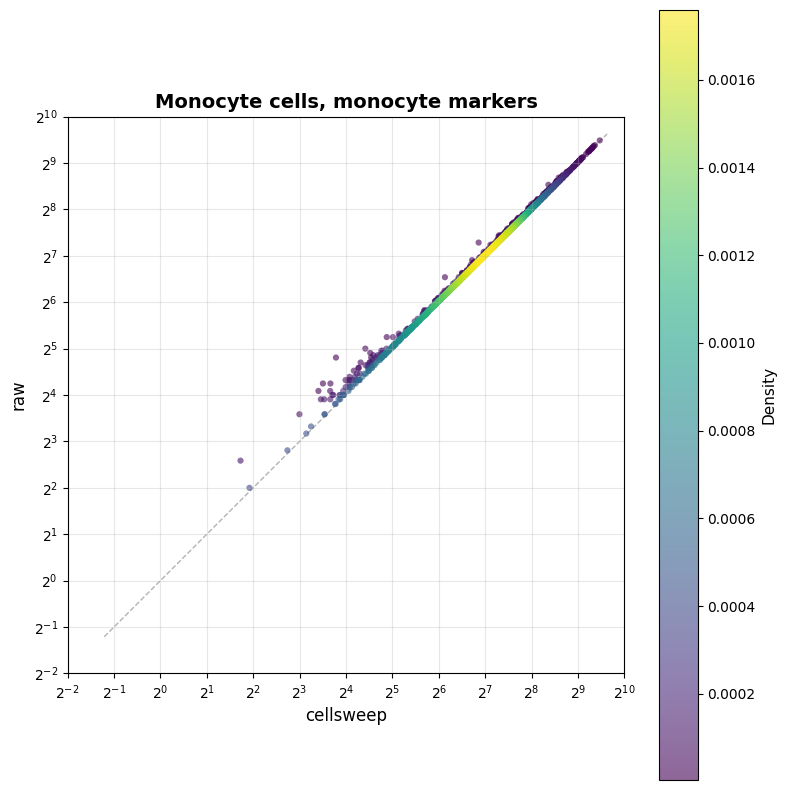

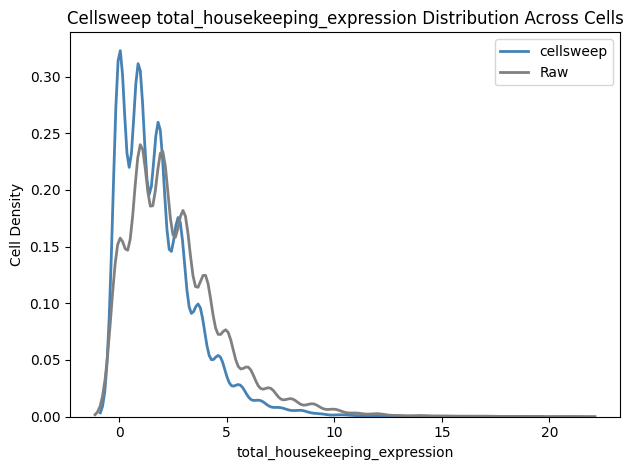

Creating scatterplot...
Calculating scatterplot...


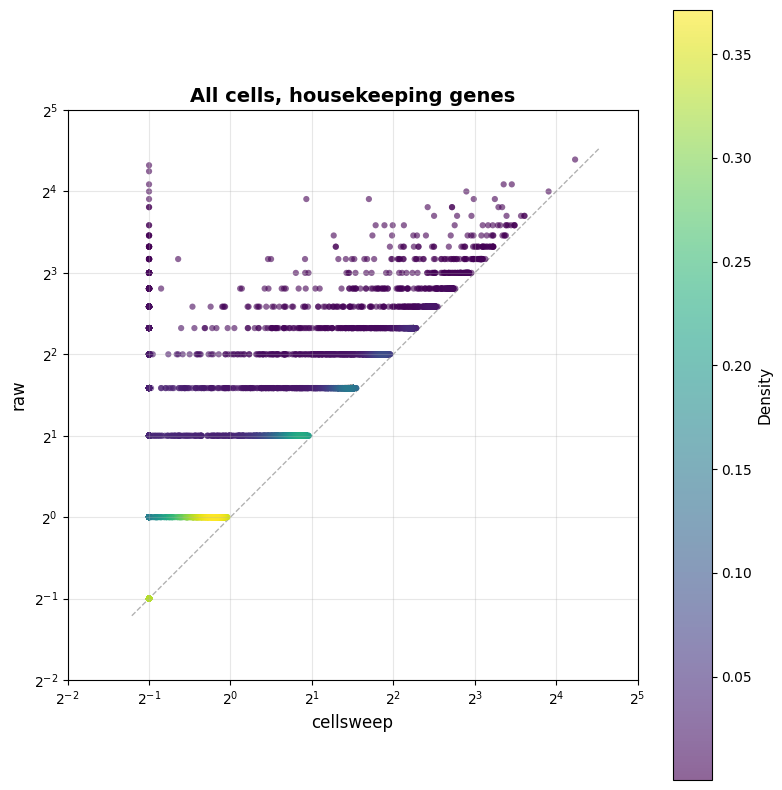

KeyError: "Values ['GACCTGGCACTTCTGC-1', 'GCTGCGACAAGCTGTT-1', 'CTGAAACTCACCACCT-1', 'AGATTGCGTTAGTGGG-1', 'ACATGGTCAGTCACTA-1', 'GCATGCGGTCTTCAAG-1', 'CTTTGCGCAGATGGCA-1', 'CTGCTGTTCTCGAGTA-1', 'CTGTTTATCTTGTCAT-1', 'AGTGTCACAGGAATCG-1', 'TACGGATAGAATAGGG-1', 'GTGTGCGCACGTAAGG-1', 'AGGGTGACAGTTCCCT-1', 'GTCGGGTCACCCATTC-1', 'AAAGCAATCACGATGT-1', 'CTCTACGTCCACTCCA-1', 'TACTTGTGTACGCACC-1', 'CTGTTTACATCCGTGG-1', 'GACTAACTCAACACAC-1', 'ACTTGTTAGCGTGAGT-1', 'TCCCGATTCAGCTGGC-1', 'GCGGGTTTCCCATTAT-1', 'CGTGTAACACGGTGTC-1', 'AAGGTTCAGTGCTGCC-1', 'CCTAAAGTCTTACCGC-1', 'AATCGGTAGGCGCTCT-1', 'TGGTTCCCATGTCGAT-1', 'GGGAGATAGGCAAAGA-1', 'TCGCGAGAGTAATCCC-1', 'TTGTAGGTCGGAAATA-1', 'TCGAGGCCAGACTCGC-1', 'TCTGGAATCTGGCGAC-1', 'GCTTCCATCGAATGGG-1', 'ACTGAACTCACCATAG-1', 'CGCGGTAAGAATCTCC-1', 'GATCGCGTCGTTTAGG-1', 'CTCGTACTCTTAGAGC-1', 'CGGTTAATCTTCTGGC-1', 'TGGCGCAGTCTCACCT-1', 'GGCTCGATCGTTTAGG-1', 'GACAGAGGTCAGTGGA-1', 'GTACTTTTCGCCAAAT-1', 'TGCGGGTCATTCTCAT-1', 'GCGCCAATCCCTCAGT-1', 'AGCGGTCCACTA

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    monocyte_neutrophil_pdc_marker_genes = ["S100A8", "S100A9", "LYZ", "CST3"]
    housekeeping_genes = ["PTPRC"]
    monocyte_neutrophil_pdc_celltypes = ["Monocytes", "Neutrophils", "DC"]
    for key, adata_processed in adata_scanpy_dict.items():
        if key == "raw" or adata_processed is None:
            continue
        show = True  # (key == "cellsweep")

        adata_raw_original = adata_scanpy_dict["raw"].copy()
        adata_processed_original = adata_processed.copy()

        if "counts" in adata_processed_original.layers:
            adata_processed_original.X = adata_processed_original.layers["counts"].copy()

        if "celltype_for_correlation" not in adata_processed_original.obs.columns:
            adata_processed_original.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")

        # monocyte marker genes in non-monocyte clusters (should move)
        adata_processed = adata_processed_original[
            ~adata_processed_original.obs["celltype_for_correlation"].isin(monocyte_neutrophil_pdc_celltypes),  # filter rows/cells to non-monocyte clusters
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_processed_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_processed.obs["total_monocyte_marker_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()

        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_raw_tmp.obs["total_monocyte_marker_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()
        adata_raw_tmp.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype_for_correlation"].reindex(adata_raw_tmp.obs.index)

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_monocyte_marker_expression"], metric="total_monocyte_marker_expression", log=False, logx=True, raw_values=adata_raw_tmp.obs["total_monocyte_marker_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_nonmonocyte_monocyte_marker_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_monocyte_marker_expression"], adata2=adata_raw_tmp.obs["total_monocyte_marker_expression"], scale="log", point_type="custom", title="Non-monocyte cells, monocyte markers", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_nonmonocyte_monocyte_marker_scatterplot.png"), show=show)

        # monocyte marker genes in monocyte clusters (should not move)
        adata_processed = adata_processed_original[
            adata_processed_original.obs["celltype_for_correlation"].isin(monocyte_neutrophil_pdc_celltypes),  # filter rows/cells to non-monocyte clusters
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_processed_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_processed.obs["total_monocyte_marker_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()

        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_raw_tmp.obs["total_monocyte_marker_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()
        adata_raw_tmp.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype_for_correlation"].reindex(adata_raw_tmp.obs.index)

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_monocyte_marker_expression"], metric="total_monocyte_marker_expression", raw_values=adata_raw_tmp.obs["total_monocyte_marker_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_monocyte_monocyte_marker_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_monocyte_marker_expression"], adata2=adata_raw_tmp.obs["total_monocyte_marker_expression"], scale="log", point_type="custom", title="Monocyte cells, monocyte markers", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_monocyte_monocyte_marker_scatterplot.png"), show=show)

        # housekeeping genes in all cells (should not move)
        adata_processed = adata_processed_original[
            :,  # all rows/cells
            [g for g in housekeeping_genes if g in adata_processed_original.var_names]  # filter cols/genes to housekeeping genes
        ].copy()
        adata_processed.obs["total_housekeeping_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()
        
        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in housekeeping_genes if g in adata_raw_original.var_names]  # filter cols/genes to housekeeping genes
        ].copy()
        adata_raw_tmp.obs["total_housekeeping_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_housekeeping_expression"], metric="total_housekeeping_expression", raw_values=adata_raw_tmp.obs["total_housekeeping_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_housekeeping_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_housekeeping_expression"], adata2=adata_raw_tmp.obs["total_housekeeping_expression"], scale="log", point_type="custom", title="All cells, housekeeping genes", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_housekeeping_scatterplot.png"), show=show)

## Look at PBMC marker correlation

In [ ]:
if dataset_name == "pbmc8k" or dataset_name == "pbmc33k":
    correlation_results, correlation_average_values = cs_utils.compute_pbmc_correlations(adata_dict)
    for tool_name, adata_processed in adata_dict.items():
        if tool_name == "raw" or adata_processed is None:
            continue
        
        show = True  # show = (tool_name == "cellsweep")
        cs_utils.plot_pbmc_correlation_scatterplot(correlation_average_values, tool_name=tool_name, out_path=os.path.join(out_dir, f"{tool_name}_pbmc_correlation_scatterplot.png"), show=show)

## How sensitive are we to celltype method? Let's compare to Leiden clustering

In [ ]:
if dataset_name == "pbmc8k":
    leiden_resolutions = [0.1, 0.5, 1.0, 1.5, 2.0, 5.0]
    for leiden_resolution in leiden_resolutions:
        print(f"Running cellsweep with leiden resolution {leiden_resolution}...")
        adata_path_cellsweep_leiden = f"{data_dir}/adata_cellsweep_leiden_{str(leiden_resolution).replace('.', '_')}.h5ad"
        cellsweep_log_file_leiden = os.path.join(out_dir, f"cellsweep_leiden_{str(leiden_resolution).replace('.', '_')}.log")

        if not os.path.exists(adata_path_cellsweep_leiden) or overwrite:
            adata = adata_raw.copy()
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].cat.add_categories(["empty"]).reindex(adata.obs.index).fillna("empty")
            adata_cellsweep_leiden = denoise_count_matrix(adata, adata_out=adata_path_cellsweep_leiden, freeze_ambient_profile=True, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file_leiden)
        else:
            adata_cellsweep_leiden = cs_utils.load_adata(adata_path_cellsweep_leiden, verbose=verbose)

        adata_cellsweep_leiden = adata_cellsweep_leiden[~adata_cellsweep_leiden.obs["is_empty"]].copy()
        adata_cellsweep_leiden.var_names_make_unique()

        number_of_clusters = adata_cellsweep_leiden.obs["celltype"].nunique()
        print("Number of clusters:", number_of_clusters)
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_leiden, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="celltype", y_axis=f"leiden ({number_of_clusters} clusters)", out_path=os.path.join(out_dir, f"cellsweep_leiden_{leiden_resolution}_matrix_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_leiden, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="celltype", y_axis=f"leiden ({number_of_clusters} clusters)", out_path=os.path.join(out_dir, f"cellsweep_leiden_{leiden_resolution}_cell_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_leiden, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="celltype", y_axis=f"leiden ({number_of_clusters} clusters)", out_path=os.path.join(out_dir, f"cellsweep_leiden_{leiden_resolution}_gene_scatterplot.png"))

## Empty Droplet analysis

In [ ]:
if dataset_name == "pbmc8k":
    #* cellsweep - thresholding + > 10 counts
    adata_dict["cellsweep"].obs["n_counts"] = np.array(adata_dict["cellsweep"].X.sum(axis=1)).ravel()
    cellsweep_cellular_barcodes = set(
        adata_dict["cellsweep"].obs.index[
            adata_dict["cellsweep"].obs["n_counts"] > 10  # more than 10 counts
        ]
    )
    cellsweep_empty_barcodes = set(adata_dict["raw"].obs.index) - cellsweep_cellular_barcodes

    #* knee plot threshold
    knee_threshold_cellular_barcodes = set(adata_dict["raw"].obs.loc[~adata_dict["raw"].obs["is_empty"]].index)
    knee_threshold_empty_barcodes = set(adata_dict["raw"].obs.index) - knee_threshold_cellular_barcodes

    #* cellbender
    cellbender_cellular_barcodes, cellbender_empty_barcodes = None, None
    if adata_dict.get("cellbender") is not None:
        cellbender_cellular_barcodes = set(adata_dict["cellbender"].obs.index)
        cellbender_empty_barcodes = set(adata_dict["raw"].obs.index) - cellbender_cellular_barcodes

    #* emptydrops
    emptydrops_barcodes_file = os.path.join(data_dir, "emptydrops_barcodes.txt")
    if not os.path.exists(emptydrops_barcodes_file) or overwrite:
        if rerun_tools:
            !{docker} run --rm \
                -w /home/ruser/work \
                -v {cellsweep_dir}:{rver_docker_workspace} \
                josephrich98/cellsweep_tutorials:decontx.0.1.0 \
                Rscript {rver_docker_workspace}/scripts/run_emptydrops.R \
                    {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                    {emptydrops_barcodes_file.replace(cellsweep_dir, rver_docker_workspace)}
        else:
            emptydrops_barcodes_url = "https://caltech.box.com/shared/static/cntju7vi06swzapuy1vka33dffxjc9xl.txt"
            !wget -O {emptydrops_barcodes_file} {emptydrops_barcodes_url}

    with open(emptydrops_barcodes_file) as f:
        emptydrops_cellular_barcodes = set(line.strip() for line in f)

    emptydrops_empty_barcodes = set(adata_dict["raw"].obs.index) - emptydrops_cellular_barcodes

    upset_data_dict_empty_barcodes = {
        # "cellsweep": cellsweep_empty_barcodes,
        "UMI_thresholding": knee_threshold_empty_barcodes,
        "emptydrops": emptydrops_empty_barcodes,
        # "cellbender": cellbender_empty_barcodes if cellbender_empty_barcodes is not None else None,
    }

    _ = cs_utils.make_upset_plot(upset_data_dict_empty_barcodes, title="Empty barcodes", out_path=os.path.join(out_dir, "empty_barcodes_upset.png"))

    upset_data_dict_cellular_barcodes = {
        # "cellsweep": cellsweep_cellular_barcodes,
        "UMI_thresholding": knee_threshold_cellular_barcodes,
        "emptydrops": emptydrops_cellular_barcodes,
        # "cellbender": cellbender_cellular_barcodes if cellbender_cellular_barcodes is not None else None,
    }

    _ = cs_utils.make_upset_plot(upset_data_dict_cellular_barcodes, title="Cellular barcodes", out_path=os.path.join(out_dir, "cellular_barcodes_upset.png"))

    adata_cellsweep_empty_barcode_method_threshold = adata_dict["cellsweep"].copy()  # what we did earlier, without the >10 counts filter
    adata_raw_empty_barcode_method_emptydrops = adata_dict["raw"].copy()
    adata_raw_empty_barcode_method_emptydrops.obs["is_empty"] = ~adata_raw_empty_barcode_method_emptydrops.obs_names.isin(emptydrops_cellular_barcodes)
    
    adata_path_cellsweep_emptydrops = os.path.join(data_dir, "adata_cellsweep_emptydrops_empty_droplets.h5ad")
    cellsweep_log_file_emptydrops = os.path.join(out_dir, "cellsweep_emptydrops_empty_droplets.log")
    if not os.path.exists(adata_path_cellsweep_emptydrops) or overwrite:
        if "celltype" not in adata_raw_empty_barcode_method_emptydrops.obs.columns:
            adata_raw_empty_barcode_method_emptydrops = cs_utils.determine_cell_types(adata_raw_empty_barcode_method_emptydrops, model_pkl=model_pkl, filter_empty=True, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
        adata_cellsweep_empty_barcode_method_emptydrops = denoise_count_matrix(adata_raw_empty_barcode_method_emptydrops, adata_out=adata_path_cellsweep_emptydrops, freeze_ambient_profile=True, max_iter=cellsweep_max_iter, empty_droplet_method=None, threads=threads, verbose=verbose, log_file=cellsweep_log_file_emptydrops)
    else:
        adata_cellsweep_empty_barcode_method_emptydrops = cs_utils.load_adata(adata_path_cellsweep_emptydrops, verbose=verbose)
    adata_cellsweep_empty_barcode_method_emptydrops = adata_cellsweep_empty_barcode_method_emptydrops[~adata_cellsweep_empty_barcode_method_emptydrops.obs["is_empty"]].copy()
    adata_cellsweep_empty_barcode_method_emptydrops.var_names_make_unique()

    cs_utils.plot_matrix_scatterplot(adata_cellsweep_empty_barcode_method_emptydrops, adata_cellsweep_empty_barcode_method_threshold, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="emptydrops", y_axis="thresholding", out_path=os.path.join(out_dir, "cellsweep_emptydrops_vs_thresholding_matrix_scatterplot.png"))
    cs_utils.plot_matrix_scatterplot(adata_cellsweep_empty_barcode_method_emptydrops, adata_cellsweep_empty_barcode_method_threshold, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="emptydrops", y_axis="thresholding", out_path=os.path.join(out_dir, "cellsweep_emptydrops_vs_thresholding_cell_scatterplot.png"))
    cs_utils.plot_matrix_scatterplot(adata_cellsweep_empty_barcode_method_emptydrops, adata_cellsweep_empty_barcode_method_threshold, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="emptydrops", y_axis="thresholding", out_path=os.path.join(out_dir, "cellsweep_emptydrops_vs_thresholding_gene_scatterplot.png"))


## How many empty droplets do we need?

In [ ]:
# adata_cellsweep_unnormalized = ad.read_h5ad(adata_path_cellsweep)
# adata_cellsweep_unnormalized = adata_cellsweep_unnormalized[~adata_cellsweep_unnormalized.obs["is_empty"]].copy()
# adata_cellsweep_unnormalized.var_names_make_unique()

if dataset_name == "pbmc8k":
    empty_droplet_numbers = [1_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]

    import random
    random.seed(42)
    done_max = True  # change to False if I want at most one negative-control plot showing all empty droplets
    for empty_droplet_number in sorted(empty_droplet_numbers):
        if empty_droplet_number >= adata_raw.obs["is_empty"].sum():
            if done_max:
                print(f"Reached maximum number of empty droplets: {adata_raw.obs['is_empty'].sum()}. Stopping cellsweep empty droplet number sweep.")
                break
            empty_droplet_number = adata_raw.obs["is_empty"].sum()
            done_max = True
        print(f"Running cellsweep with empty droplet number {empty_droplet_number}...")
        adata_path_cellsweep_empty_droplet = f"{data_dir}/adata_cellsweep_empty_droplet_{str(empty_droplet_number).replace('.', '_')}.h5ad"
        cellsweep_log_file_empty_droplet = os.path.join(out_dir, f"cellsweep_empty_droplet_{str(empty_droplet_number).replace('.', '_')}.log")

        if not os.path.exists(adata_path_cellsweep_empty_droplet) or overwrite:
            adata = adata_raw.copy()
            if "celltype" not in adata.obs.columns:
                adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
            # keep only "empty_droplet_number" empty droplets for clustering
            
            empty_droplet_barcodes = adata.obs.index[adata.obs["is_empty"]].tolist()
            if empty_droplet_number > len(empty_droplet_barcodes):
                print(f"Warning: requested empty_droplet_number {empty_droplet_number} exceeds available empty droplets {len(empty_droplet_barcodes)}. Using all available empty droplets.")
                continue
            selected_empty_droplet_barcodes = set(random.sample(empty_droplet_barcodes, empty_droplet_number))
            adata_tmp = adata[
                adata.obs.index.isin(
                    adata.obs.index[~adata.obs["is_empty"]].tolist() + list(selected_empty_droplet_barcodes)
                )
            ].copy()
            adata_cellsweep_empty_droplet = denoise_count_matrix(adata_tmp, adata_out=adata_path_cellsweep_empty_droplet, freeze_ambient_profile=True, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file_empty_droplet)
        else:
            adata_cellsweep_empty_droplet = cs_utils.load_adata(adata_path_cellsweep_empty_droplet, verbose=verbose)

        adata_cellsweep_empty_droplet = adata_cellsweep_empty_droplet[~adata_cellsweep_empty_droplet.obs["is_empty"]].copy()
        adata_cellsweep_empty_droplet.var_names_make_unique()

        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_empty_droplet, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="all empty droplets", y_axis=f"{empty_droplet_number} empty droplets", title=f"{empty_droplet_number} vs all empty droplets matrix scatterplot", out_path=os.path.join(out_dir, f"cellsweep_empty_droplets_{empty_droplet_number}_matrix_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_empty_droplet, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="all empty droplets", y_axis=f"{empty_droplet_number} empty droplets", title=f"{empty_droplet_number} vs all empty droplets cell scatterplot", out_path=os.path.join(out_dir, f"cellsweep_empty_droplets_{empty_droplet_number}_cell_scatterplot.png"))
        cs_utils.plot_matrix_scatterplot(adata_dict["cellsweep"], adata_cellsweep_empty_droplet, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="all empty droplets", y_axis=f"{empty_droplet_number} empty droplets", title=f"{empty_droplet_number} vs all empty droplets gene scatterplot", out_path=os.path.join(out_dir, f"cellsweep_empty_droplets_{empty_droplet_number}_gene_scatterplot.png"))

## Bonus: Number of parameters in cellsweep and CellBender

In [ ]:
cellsweep_parameters = cs_utils.count_cellsweep_parameters(cellsweep_log_file)
print(cellsweep_parameters)

In [ ]:
if "cellbender" in alternative_tools and os.path.exists(cellbender_ckpt):
    cellbender_parameters = cs_utils.count_cellbender_parameters(cellbender_ckpt)
    print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")